#### IMPORTS

In [36]:
import torch

import numpy as np
import matplotlib.pyplot as plt

from config import *
from ontology2.classifier_builder.device import DEVICE
from ontology2.classifier_builder.wrapper import build_model, model_defaults

#### CUDA

In [37]:
try:
    print(f'Using: {torch.cuda.get_device_name(DEVICE)}')
except ValueError:
    print(f'Using: CPU')

Using: AMD Radeon RX 6600


### NETWORK INSTANTIATION

In [38]:
m_defaults = model_defaults()
m_defaults['device'] = 'cpu'
m_defaults['name'] = 'bert'
m_defaults['version'] = 27
model = build_model(path=f'{RESOURCES}/models', **m_defaults)

### PLOTS

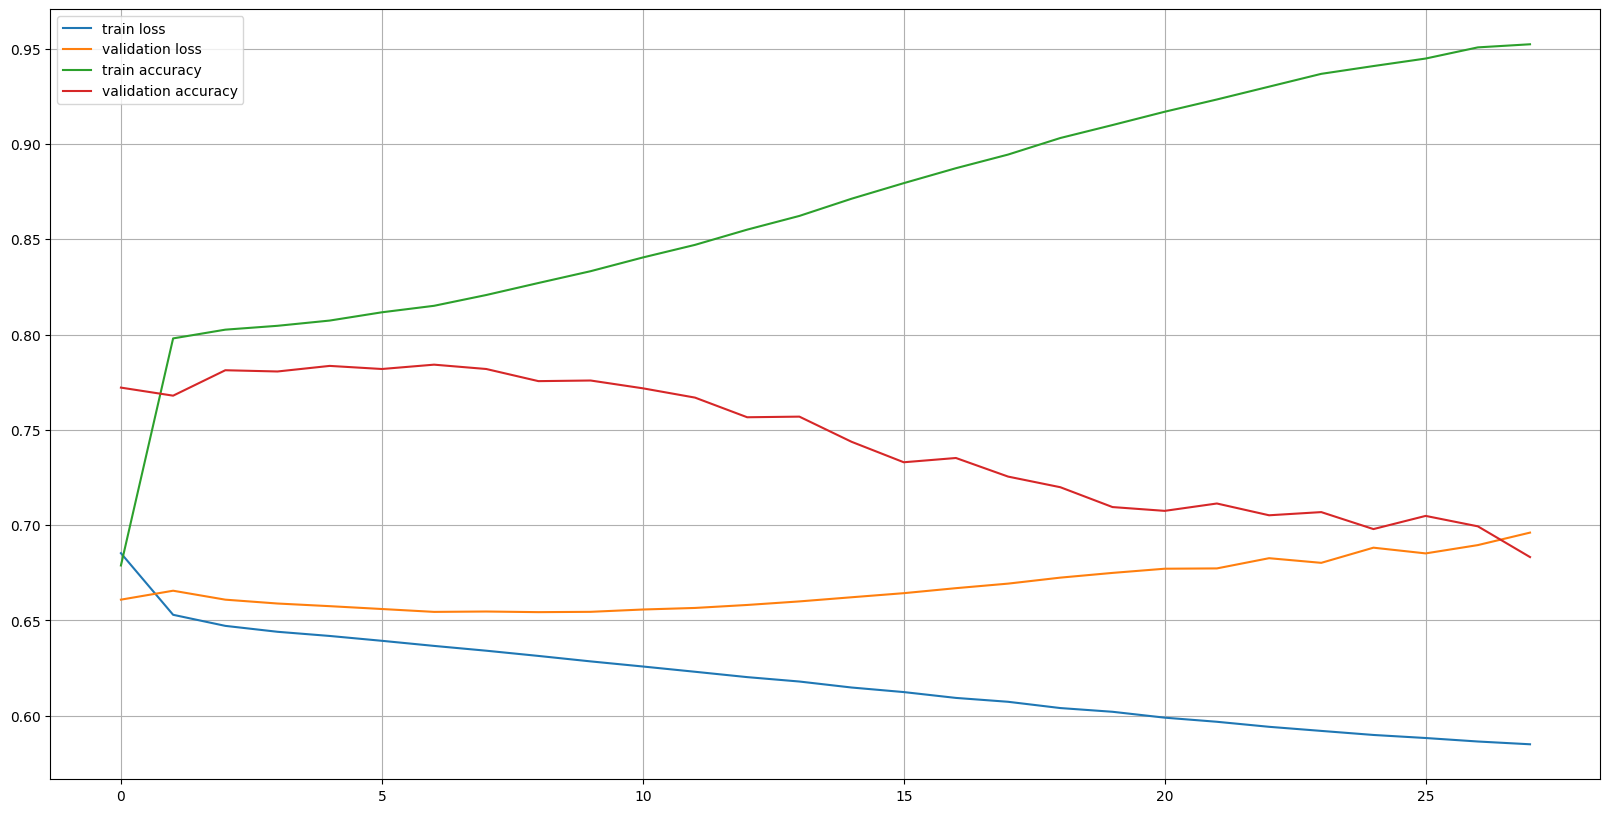

TA=0.9523292824074074, VA=0.6831967733739838


In [39]:
stats = model.stats_mem

plt.figure(figsize=(20,10))
plt.grid()
plt.plot([s['t_loss'] for s in stats])
plt.plot([s['v_loss'] for s in stats])
plt.plot([s['t_accuracy'] for s in stats])
plt.plot([s['v_accuracy'] for s in stats])
plt.legend(['train loss', 'validation loss', 'train accuracy', 'validation accuracy'])
plt.show()

print(f'TA={stats[-1]["t_accuracy"]}, VA={stats[-1]["v_accuracy"]}')

In [40]:
best = np.argmin([s['v_loss'] for s in stats])
print(f'best epoch: {best}, score: {stats[best]["t_accuracy"]}, score: {stats[best]["v_accuracy"]}')

best epoch: 8, score: 0.8270440099516726, score: 0.7755335365853658
